In this notebook we will take the pre-processed data from preprocessing.py file
1- In the first cell we look into the data and see the data heads 
2- we will plot the distribution of different classes in our dataset 
3- we will use the TF-IDF vectorization to vectorize the data and than simply use the traditional machine learning techinique logistic regression for classification
4- In the 4th cell we will see the performance of model on new data 

In [ ]:

   #-------- Main Script for EDA and TF-IDF with Logistic Regression--------#

import sys
import os

sys.path.append('../src')

from preprocessing import load_data, encode_labels

train = load_data('../data/train.txt')
val = load_data('../data/val.txt')
test = load_data('../data/test.txt')

print(train.head())
print(train['label'].value_counts())

                                                text    label
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger
label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


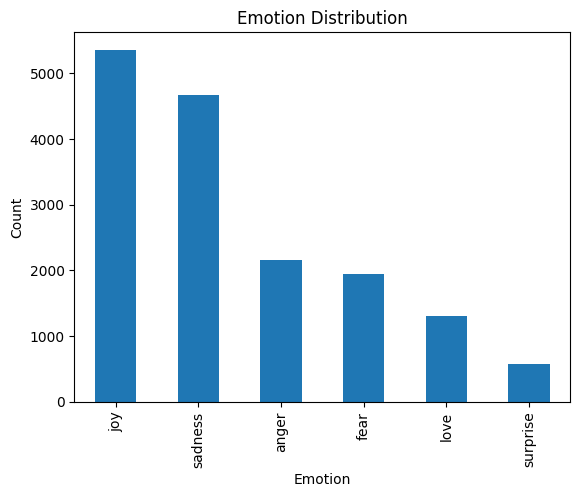

In [ ]:

   #-------- EDA Module--------#

import matplotlib.pyplot as plt

train['label'].value_counts().plot(kind='bar')
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

In [ ]:

     #-------- TF-IDF and Logistic Regression Module--------#

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train['text'])
X_val = vectorizer.transform(val['text'])
X_test = vectorizer.transform(test['text'])

y_train = train['label']
y_val = val['label']
y_test = test['label']

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.90      0.82      0.86       275
        fear       0.89      0.79      0.84       224
         joy       0.84      0.96      0.89       695
        love       0.83      0.60      0.69       159
     sadness       0.90      0.93      0.91       581
    surprise       0.85      0.52      0.64        66

    accuracy                           0.87      2000
   macro avg       0.87      0.77      0.81      2000
weighted avg       0.87      0.87      0.86      2000



In [4]:


    #------- Checking model predictions on new examples -------#


def classify_texts(texts, true_labels=None):
    X_new = vectorizer.transform(texts)        # use the fitted TF‑IDF
    preds = model.predict(X_new)               # logistic regression prediction
    for txt, p in zip(texts, preds):
        print(f"'{txt}'  →  {p}")
    if true_labels is not None:
        print("\nreport:")
        print(classification_report(true_labels, preds))
    return preds

# example usage
examples = [
    "i am feeling very happy today!",
    "i feel so depressed and sad.",
    "why does everything make me angry?"
]
classify_texts(examples)


'i am feeling very happy today!'  →  joy
'i feel so depressed and sad.'  →  sadness
'why does everything make me angry?'  →  anger


array(['joy', 'sadness', 'anger'], dtype=object)